# Experiment Walkthrough — Polymarket BTC/ETH Crypto Markets

This notebook loads the artifacts produced by `mlns_project.cli.run_pipeline` against the real Polymarket dataset (`backtest_sample.db`, Apr 2025 – Feb 2026) and renders the headline findings: dataset summary, per-split metrics for all five models, the example cohort graph, and the test-split calibration plot.

To regenerate the artifacts first, run:

```bash
py -3 -m mlns_project.cli.run_pipeline --config config/project.real.toml
```

The synthetic configuration (`config/project.synthetic.toml`) uses the same code path and writes to `data/processed` / `outputs`; switch the paths in the next cell if you want to inspect that run instead.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

workspace = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

# Real-data run (project.real.toml). Swap to processed/outputs for the synthetic config.
processed_dir = workspace / 'data' / 'processed_real'
tables_dir = workspace / 'outputs_real' / 'tables'
figures_dir = workspace / 'outputs_real' / 'figures'

experiment_table = pd.read_csv(processed_dir / 'experiment_table.csv')
predictions = pd.read_csv(processed_dir / 'predictions.csv')
metrics_by_split = pd.read_csv(processed_dir / 'metrics_by_split.csv')
results_table = pd.read_csv(tables_dir / 'results_table.csv')
dataset_summary = pd.read_csv(tables_dir / 'dataset_summary.csv')

print(f'Loaded {len(experiment_table)} markets across {experiment_table["cohort_id"].nunique()} cohorts.')
print('Split sizes:')
print(experiment_table['split'].value_counts())

Loaded 4081 markets across 397 cohorts.
Split sizes:
split
train         2047
test          1032
validation    1002
Name: count, dtype: int64


In [2]:
dataset_summary

,metric,value
0,markets,4081
1,cohorts,397
2,assets,"BTC, ETH"
3,contract_types,"above, below"
4,start_settlement,2025-04-11T00:00:00+00:00
5,end_settlement,2026-02-11T00:00:00+00:00
6,avg_markets_per_cohort,10.279596977329975


In [3]:
print('Test split (sorted by Brier score):')
results_table

Test split (sorted by Brier score):


,split,model,n_samples,brier_score,log_loss,ece
0,test,Graph (node2vec),1032,0.054195,0.189800,0.032355
1,test,Graph (combined),1032,0.054327,0.190012,0.033866
2,test,Tabular model,1032,0.056945,0.196596,0.018119
3,test,Graph (centrality),1032,0.057408,0.197847,0.024069
4,test,Crowd baseline,1032,0.058983,0.209440,0.030969


In [4]:
print('Per-split metrics for all five models:')
metrics_by_split.pivot(index='model', columns='split', values='brier_score').round(4)

Per-split metrics for all five models:


split,test,train,validation
model,,,
Crowd baseline,0.0590,0.0793,0.0502
Graph (centrality),0.0574,0.0774,0.0555
Graph (combined),0.0543,0.0728,0.0605
Graph (node2vec),0.0542,0.0733,0.0603
Tabular model,0.0569,0.0781,0.0553


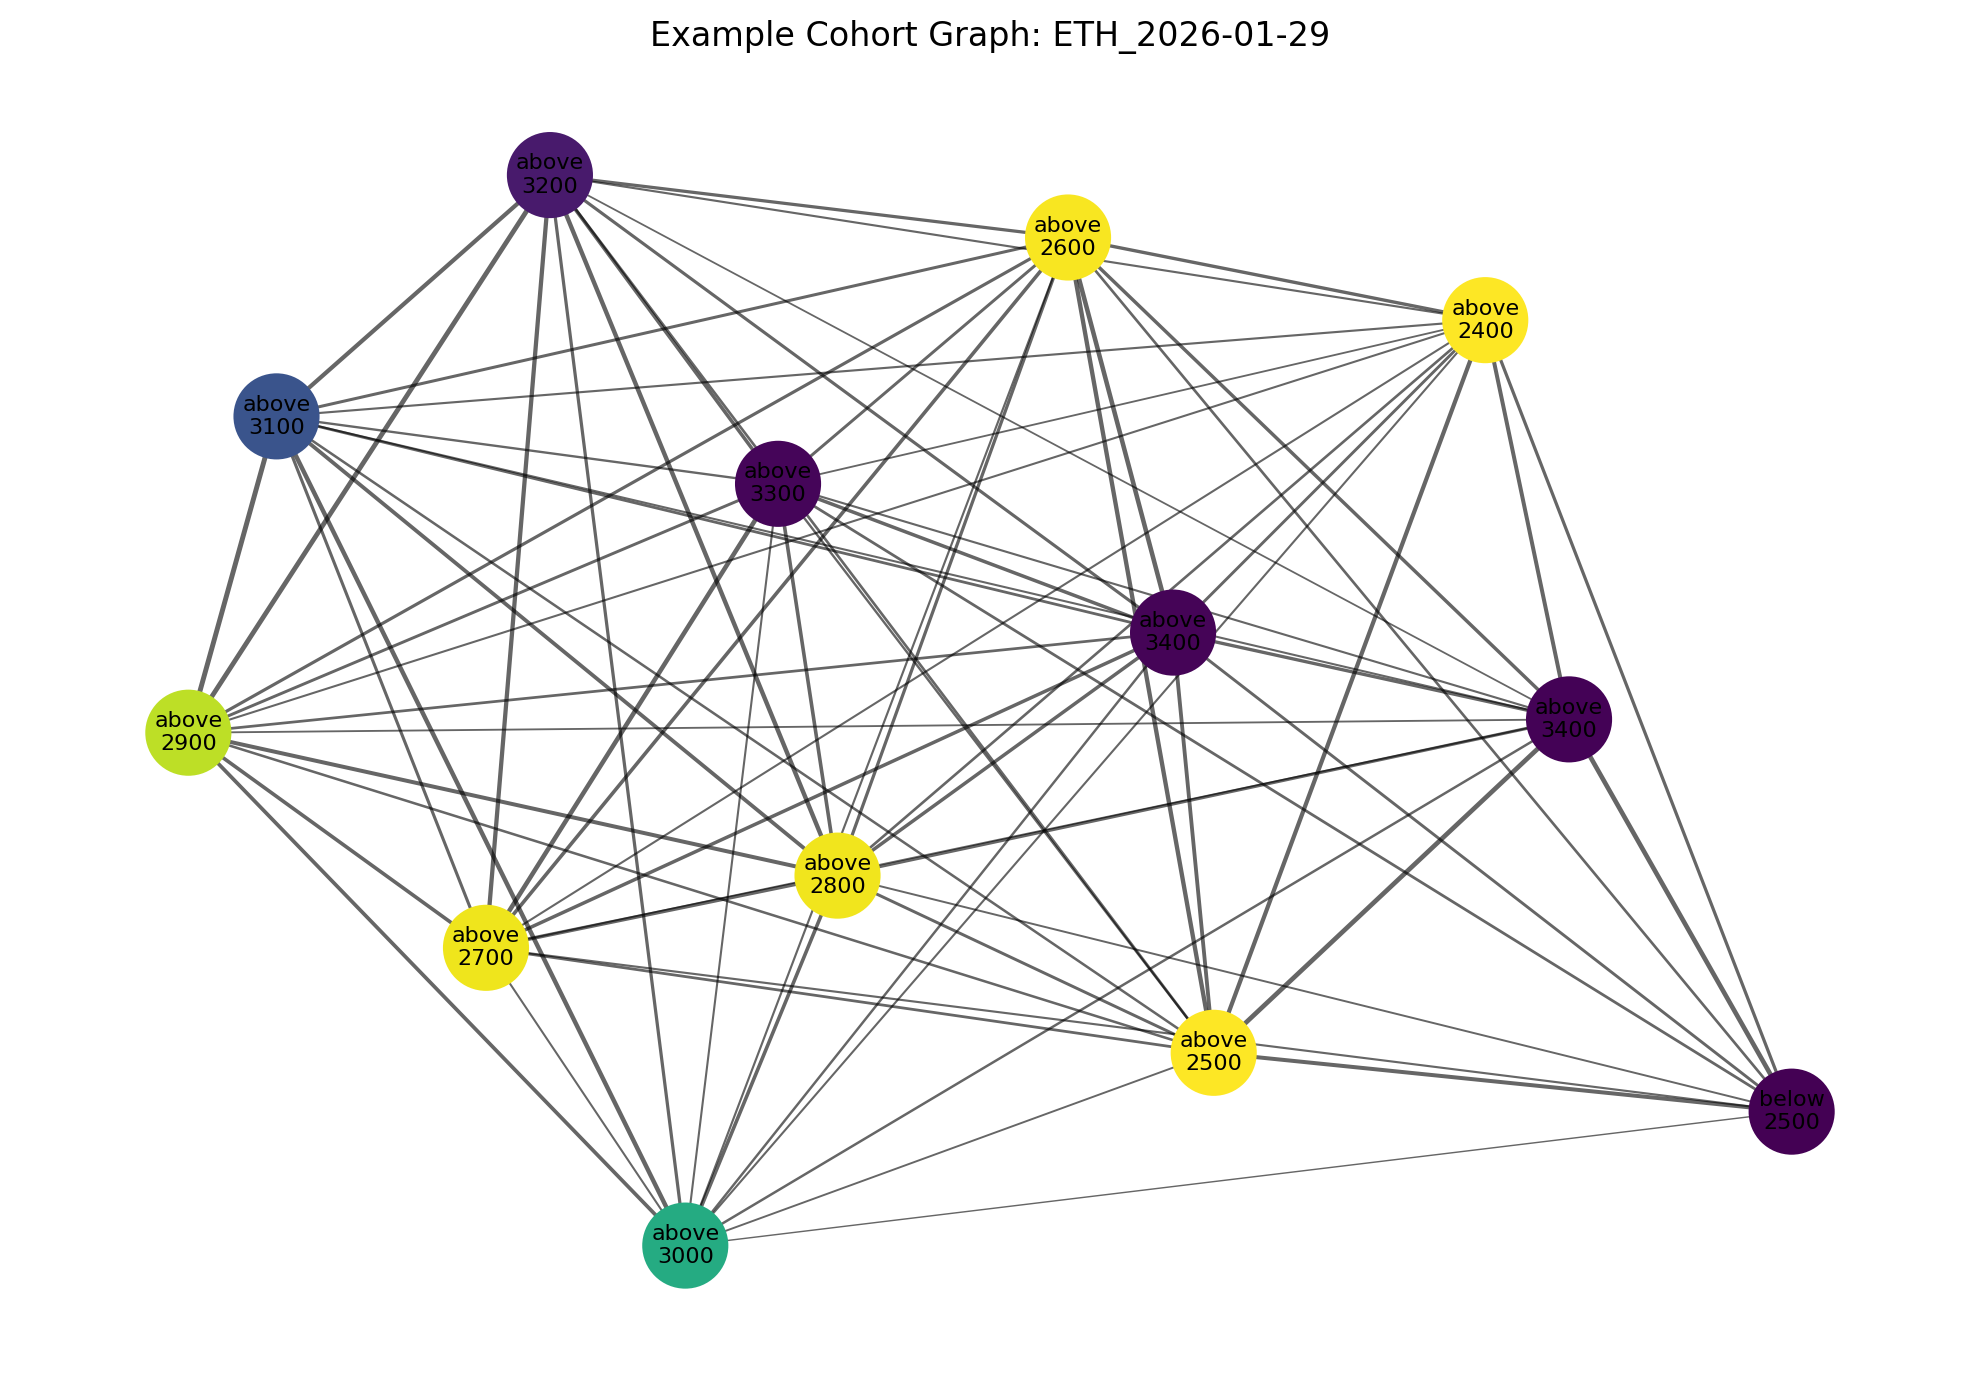

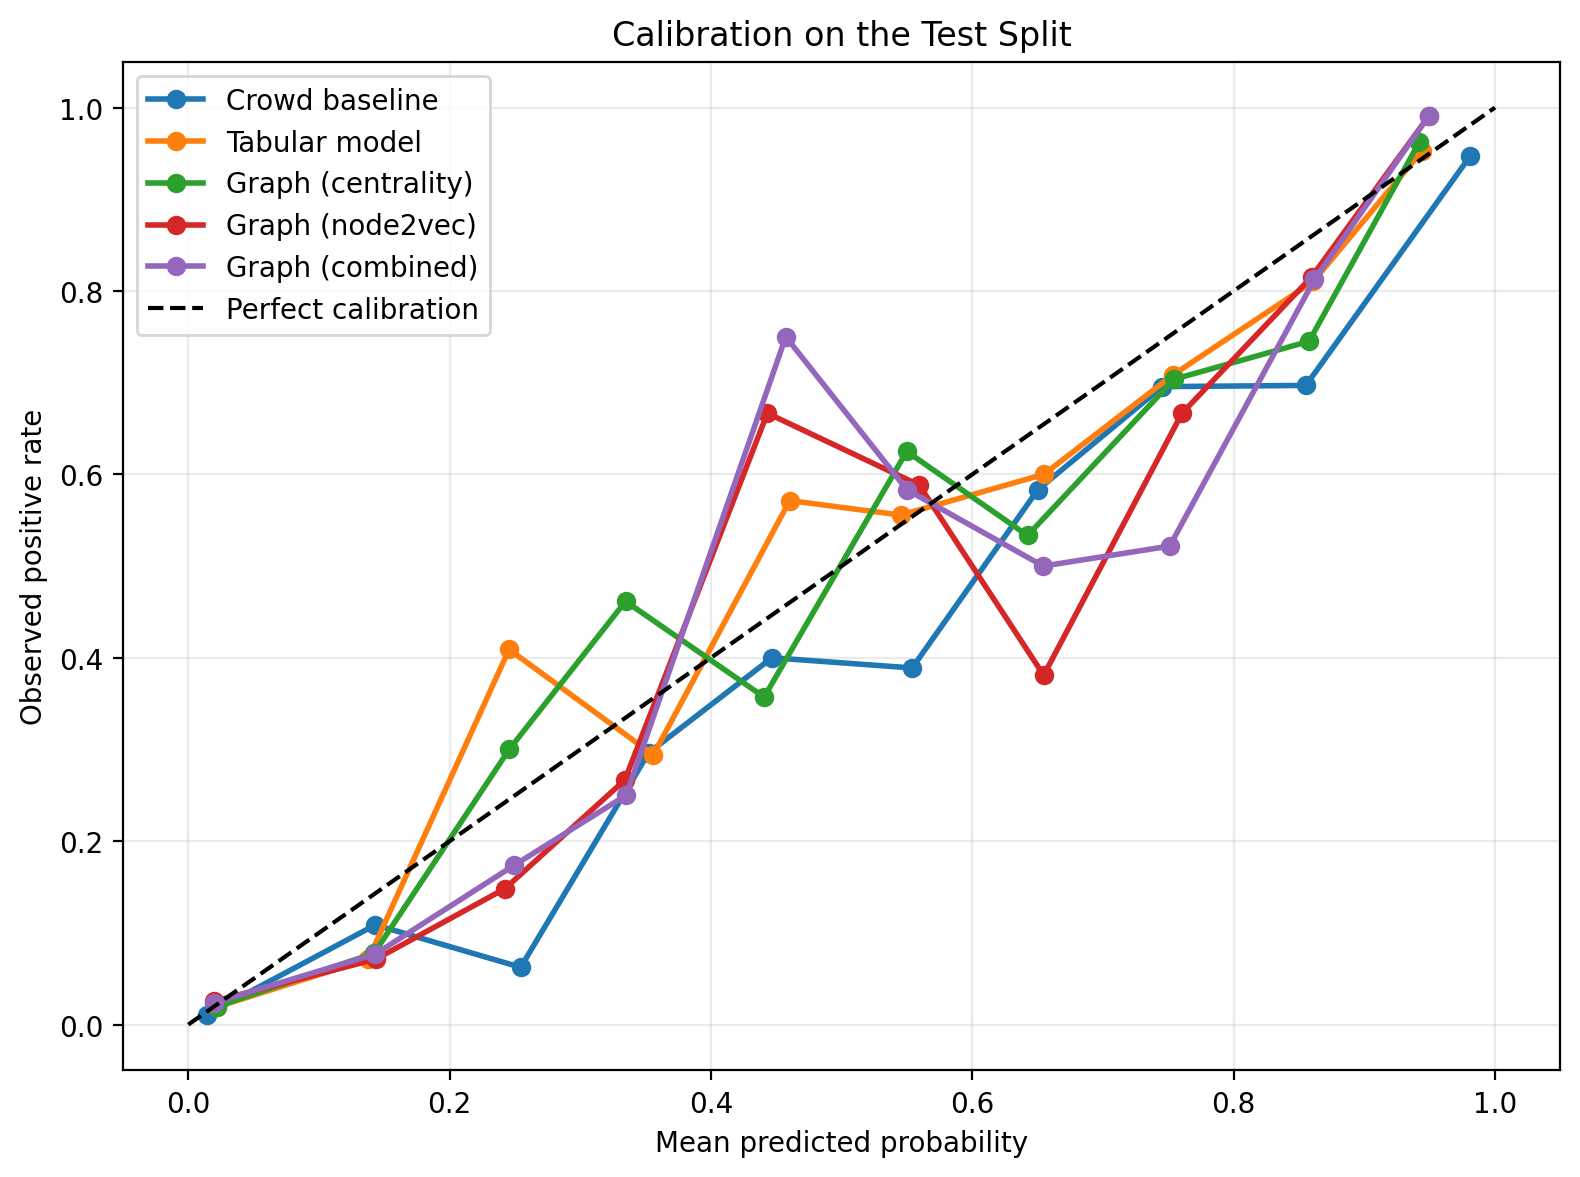

In [5]:
display(Image(filename=str(figures_dir / 'example_cohort_graph.png')))
display(Image(filename=str(figures_dir / 'calibration_plot.png')))